In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

X = pd.read_csv("X.csv")
y = pd.read_csv("y.csv").squeeze()

In [5]:
X.head()

,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio
0,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90
1,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74
2,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89
3,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00
4,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40


In [6]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (19368, 8)
y Shape : (19368,)


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19368 entries, 0 to 19367
Data columns (total 8 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Total Bilirubin                       19368 non-null  float64
 1   Direct Bilirubin                      19368 non-null  float64
 2   Alkphos Alkaline Phosphotase          19368 non-null  float64
 3   Sgpt Alamine Aminotransferase         19368 non-null  float64
 4   Sgot Aspartate Aminotransferase       19368 non-null  float64
 5   Total Protiens                        19368 non-null  float64
 6   ALB Albumin                           19368 non-null  float64
 7   A/G Ratio Albumin and Globulin Ratio  19368 non-null  float64
dtypes: float64(8)
memory usage: 1.2 MB


In [8]:
X.describe()

,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio
count,19368.000000,19368.000000,19368.000000,19368.000000,19368.000000,19368.000000,19368.000000,19368.000000
mean,3.249169,1.484882,286.490397,79.518123,109.394827,6.496344,3.140169,0.945530
std,6.035743,2.833589,235.878731,179.109663,276.253721,1.079620,0.785117,0.318386
min,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000
25%,0.800000,0.200000,177.000000,23.000000,26.000000,5.800000,2.600000,0.700000
50%,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000
75%,2.600000,1.200000,293.000000,60.000000,87.000000,7.200000,3.800000,1.100000
max,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000


In [9]:
X.isnull().sum()

,0
Total Bilirubin,0
Direct Bilirubin,0
Alkphos Alkaline Phosphotase,0
Sgpt Alamine Aminotransferase,0
Sgot Aspartate Aminotransferase,0
Total Protiens,0
ALB Albumin,0
A/G Ratio Albumin and Globulin Ratio,0


In [10]:
y.value_counts()

,count
Result,
1,13811
0,5557


In [11]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [12]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [13]:
y_pred = dt_model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.9878678368611254


In [15]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1112
           1       0.99      0.99      0.99      2762

    accuracy                           0.99      3874
   macro avg       0.99      0.98      0.99      3874
weighted avg       0.99      0.99      0.99      3874



In [16]:
print(confusion_matrix(
    y_test,
    y_pred
))

[[1087   25]
 [  22 2740]]


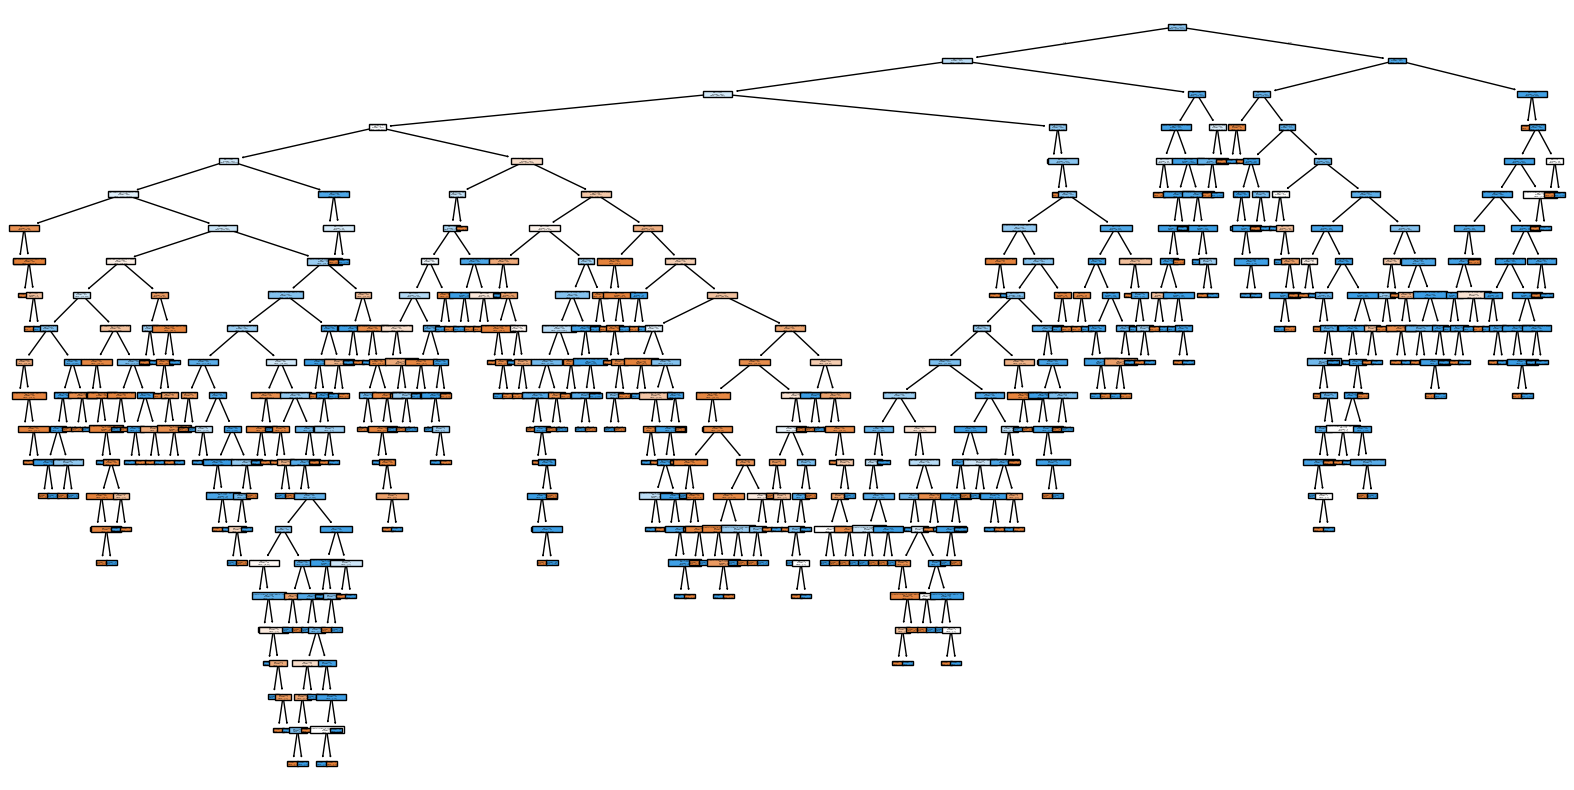

In [17]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns
)

plt.show()

In [18]:
print("Tree Depth =", dt_model.get_depth())

Tree Depth = 22


In [19]:
print("Number of Leaves =", dt_model.get_n_leaves())

Number of Leaves = 326


In [20]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": dt_model.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,Sgpt Alamine Aminotransferase,0.175075
0,Total Bilirubin,0.162687
2,Alkphos Alkaline Phosphotase,0.155104
4,Sgot Aspartate Aminotransferase,0.150210
5,Total Protiens,0.132587
6,ALB Albumin,0.118004
7,A/G Ratio Albumin and Globulin Ratio,0.073561
1,Direct Bilirubin,0.032771


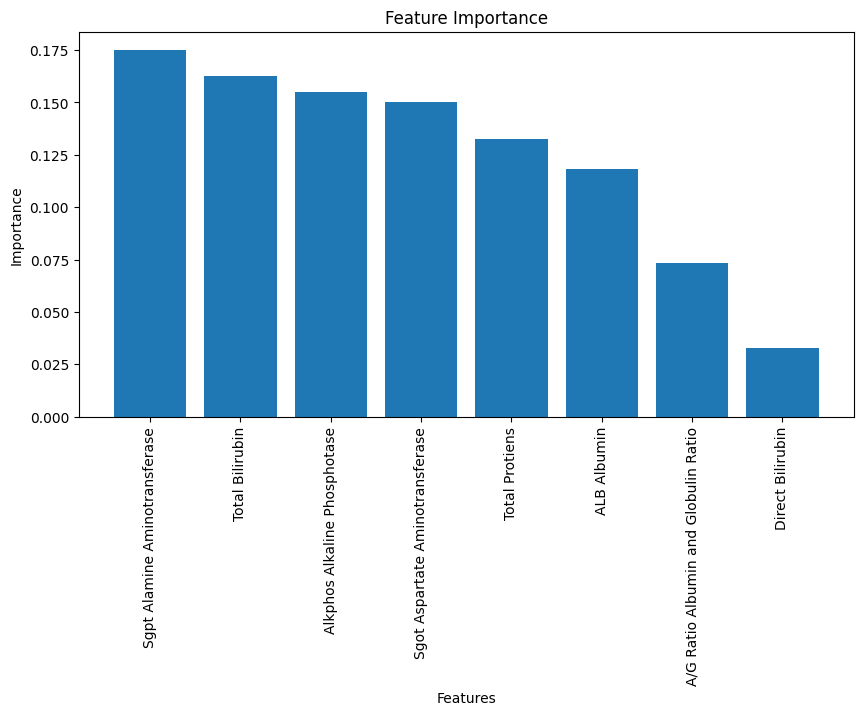

In [21]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()

In [22]:
comparison = pd.DataFrame({

    "Actual": y_test,
    "Predicted": y_pred

})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [23]:
sample = X_test.iloc[[0]]

prediction = dt_model.predict(sample)

print("Prediction =", prediction)

Prediction = [0]
